* ### Analyse 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost

In [2]:
os.chdir(path="/home/donerick/Challenge 30 Days ML")

In [3]:
data_air = pd.read_csv(pathlib.Path("data/raw/hourly_quality_air_data.csv"))

data_meteo = pd.read_csv(pathlib.Path("data/raw/hourly_meteo_data.csv"))

In [4]:
data_air.head()

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,1610.0,23.574997,23.574997
1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,1637.0,26.125000,26.125000
2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,1586.0,29.491669,29.491669
3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,1492.0,32.333332,32.333332
4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,1420.0,34.891666,34.891666


In [5]:
data_air.shape

(4536, 12)

In [6]:
data_meteo.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,rain
0,2025-09-30 00:00:00+00:00,25.05,91.677830,29.929287,0.0,1013.30330,1014.0,6.698806,239.30035,25.30,0.376,0.0
1,2025-09-30 01:00:00+00:00,25.00,92.785780,30.231480,0.0,1012.60370,1013.3,4.913044,241.55717,25.15,0.373,0.0
2,2025-09-30 02:00:00+00:00,25.35,90.872086,30.135036,0.0,1012.20465,1012.9,7.970972,205.40767,26.05,0.327,0.0
3,2025-09-30 03:00:00+00:00,25.35,90.872086,29.911430,0.0,1012.00476,1012.7,9.504272,217.30403,25.70,0.326,0.0
4,2025-09-30 04:00:00+00:00,25.25,91.689690,29.813267,0.0,1011.60504,1012.3,9.703319,220.48593,25.40,0.324,0.0


In [7]:
data_meteo.dtypes

date                             str
temperature_2m               float64
relative_humidity_2m         float64
apparent_temperature         float64
precipitation                float64
surface_pressure             float64
pressure_msl                 float64
wind_speed_10m               float64
wind_direction_10m           float64
soil_temperature_0_to_7cm    float64
soil_moisture_0_to_7cm       float64
rain                         float64
dtype: object

In [8]:
def merge_sources(meteo: pd.DataFrame, air: pd.DataFrame) -> pd.DataFrame:
    """
    Merge météo + qualité d'air sur la colonne 'date' (timestamp exact).
    Les deux APIs Open-Meteo produisent des timestamps horaires alignés —
    un inner join suffit..
    """
    meteo['date'] = pd.to_datetime(meteo["date"], utc=True)
    air['date'] = pd.to_datetime(air['date'], utc=True)
 
    merged = pd.merge(
        meteo,
        air,
        on='date',
        how="inner"
        ).reset_index()
 
 
    before = len(merged)
    merged = merged.dropna(subset=["pm10", "pm2_5", "temperature_2m"])
    after  = len(merged)
    if before != after:
        print(f"Lignes supprimées après merge (NaN critiques) : {before - after}")
 
    print(f"Après merge : {len(merged)} lignes, {merged.shape[1]} colonnes")
    return merged
 
 

In [9]:
merge_sources(data_air, data_meteo)

Après merge : 4200 lignes, 24 colonnes


,index,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,...,relative_humidity_2m,apparent_temperature,precipitation,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,rain
0,0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,...,91.677830,29.929287,0.0,1013.30330,1014.0,6.698806,239.30035,25.30,0.376,0.0
1,1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,...,92.785780,30.231480,0.0,1012.60370,1013.3,4.913044,241.55717,25.15,0.373,0.0
2,2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,...,90.872086,30.135036,0.0,1012.20465,1012.9,7.970972,205.40767,26.05,0.327,0.0
3,3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,...,90.872086,29.911430,0.0,1012.00476,1012.7,9.504272,217.30403,25.70,0.326,0.0
4,4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,...,91.689690,29.813267,0.0,1011.60504,1012.3,9.703319,220.48593,25.40,0.324,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,4195,2026-03-23 19:00:00+00:00,5.800000,10.500000,222.0,446.0,0.5,51.0,1.5,NaN,...,73.051100,33.696594,0.0,1007.21814,1007.9,17.012617,209.81998,34.00,0.073,0.0
4196,4196,2026-03-23 20:00:00+00:00,8.100000,12.700000,224.0,447.0,0.6,49.0,1.8,NaN,...,74.531060,33.121952,0.0,1007.61725,1008.3,17.997300,210.66885,32.85,0.073,0.0
4197,4197,2026-03-23 21:00:00+00:00,9.400000,13.800000,222.0,447.0,0.7,48.0,2.1,NaN,...,76.747260,33.121070,0.0,1007.91610,1008.6,16.824945,206.01672,32.00,0.073,0.0
4198,4198,2026-03-23 22:00:00+00:00,10.300000,14.500000,218.0,447.0,0.8,47.0,2.3,NaN,...,79.017166,32.843060,0.0,1009.21466,1009.9,16.434305,208.81070,31.25,0.074,0.0


In [10]:
df_merged = merge_sources(data_air, data_meteo)

df_merged.describe()

Après merge : 4200 lignes, 24 colonnes


,index,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,...,relative_humidity_2m,apparent_temperature,precipitation,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,rain
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,0.0,4200.000000,...,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000
mean,2099.500000,19.108500,36.943571,244.826667,446.733333,0.893476,61.690714,2.727095,NaN,1377.970714,...,79.111915,32.723925,0.061476,1010.071965,1010.759548,10.960793,219.037065,30.033107,0.119357,0.061476
std,1212.579894,9.384826,24.418301,42.369702,5.544841,0.470213,18.738631,2.239695,NaN,29.767206,...,7.869572,1.631451,0.351029,1.821530,1.823949,3.398159,30.918991,2.967568,0.057275,0.351029
min,0.000000,4.000000,6.600000,136.000000,432.000000,0.200000,18.000000,0.200000,NaN,1328.000000,...,29.478800,27.294014,0.000000,1004.816400,1005.500000,0.000000,2.862346,23.600000,0.060000,0.000000
25%,1049.750000,12.700000,21.600000,217.000000,444.000000,0.600000,48.000000,1.100000,NaN,1362.000000,...,73.534100,31.756545,0.000000,1008.814500,1009.500000,8.797931,204.443940,27.850000,0.093000,0.000000
50%,2099.500000,16.700001,29.200001,240.000000,447.000000,0.800000,59.000000,2.300000,NaN,1373.000000,...,80.706218,32.597853,0.000000,1010.108600,1010.800000,11.272657,217.504210,29.250000,0.101000,0.000000
75%,3149.250000,22.725000,43.900002,269.000000,450.000000,1.100000,72.000000,3.500000,NaN,1385.000000,...,84.910840,33.607937,0.000000,1011.407737,1012.100000,13.246826,231.842730,32.212500,0.114000,0.000000
max,4199.000000,100.800003,191.399994,657.000000,473.000000,6.500000,162.000000,27.000000,NaN,1654.000000,...,96.440414,38.306320,8.500000,1015.102600,1015.800000,25.872454,360.000000,38.700000,0.436000,8.500000


In [11]:
df_merged.isnull().sum()

index                           0
date                            0
pm2_5                           0
pm10                            0
carbon_monoxide                 0
carbon_dioxide                  0
sulphur_dioxide                 0
ozone                           0
nitrogen_dioxide                0
formaldehyde                 4200
methane                         0
european_aqi                    0
european_aqi_pm2_5              0
temperature_2m                  0
relative_humidity_2m            0
apparent_temperature            0
precipitation                   0
surface_pressure                0
pressure_msl                    0
wind_speed_10m                  0
wind_direction_10m              0
soil_temperature_0_to_7cm       0
soil_moisture_0_to_7cm          0
rain                            0
dtype: int64

In [12]:
df_merged= df_merged.drop(columns=["index", "formaldehyde"], axis=0)
df_merged.sample(10)

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,methane,european_aqi,...,relative_humidity_2m,apparent_temperature,precipitation,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,rain
1459,2025-11-29 19:00:00+00:00,15.400000,21.200001,283.0,448.0,0.8,60.0,3.0,1387.0,31.291666,...,78.934150,32.788986,0.0,1006.91460,1007.6,10.086427,214.82455,32.40,0.096,0.0
1225,2025-11-20 01:00:00+00:00,15.900000,24.400000,261.0,451.0,0.8,61.0,3.1,1404.0,38.249996,...,87.022995,32.429340,0.0,1010.21045,1010.9,10.234705,214.24908,28.80,0.103,0.0
3048,2026-02-04 00:00:00+00:00,17.200001,24.600000,297.0,450.0,0.8,58.0,2.4,1383.0,40.966660,...,83.543610,32.960766,0.0,1011.61140,1012.3,12.514855,229.66693,28.60,0.097,0.0
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,1610.0,23.574997,...,91.677830,29.929287,0.0,1013.30330,1014.0,6.698806,239.30035,25.30,0.376,0.0
2414,2026-01-08 14:00:00+00:00,21.299999,51.500000,217.0,444.0,0.5,82.0,0.7,1359.0,37.270832,...,69.471725,35.546820,0.0,1010.61676,1011.3,10.404249,217.26648,31.75,0.123,0.0
1162,2025-11-17 10:00:00+00:00,10.400000,15.600000,238.0,439.0,0.8,78.0,1.1,1408.0,39.274998,...,70.451660,32.897810,0.1,1013.51135,1014.2,6.439876,153.43501,30.30,0.090,0.1
2763,2026-01-23 03:00:00+00:00,30.700001,44.099998,280.0,454.0,1.4,63.0,5.2,1379.0,63.260002,...,91.502550,32.353855,0.0,1009.40970,1010.1,8.338489,283.73630,27.65,0.106,0.0
3739,2026-03-04 19:00:00+00:00,16.400000,35.200001,214.0,446.0,0.5,51.0,1.4,1356.0,31.062500,...,74.754555,33.966324,0.0,1008.81647,1009.5,12.425216,218.53021,32.50,0.099,0.0
648,2025-10-27 00:00:00+00:00,13.100000,16.400000,202.0,446.0,1.0,41.0,3.1,1381.0,30.583328,...,83.934100,31.455837,0.0,1012.40857,1013.1,12.039833,211.55133,28.15,0.098,0.0
3510,2026-02-23 06:00:00+00:00,28.500000,78.699997,215.0,450.0,0.6,45.0,3.0,1374.0,84.551659,...,86.809390,32.831753,0.0,1007.61350,1008.3,12.932471,235.20390,28.60,0.080,0.0


In [13]:
df_merged.to_csv('data/processed/df.csv',index=False)

In [14]:
corr = df_merged.corr(numeric_only=True)["pm2_5"].sort_values(ascending=False)
print(corr)

pm2_5                        1.000000
pm10                         0.809508
european_aqi_pm2_5           0.716349
european_aqi                 0.697257
carbon_monoxide              0.575981
sulphur_dioxide              0.525941
nitrogen_dioxide             0.462077
carbon_dioxide               0.418343
methane                      0.288674
ozone                        0.191896
apparent_temperature         0.111231
relative_humidity_2m         0.084337
wind_direction_10m           0.014671
temperature_2m              -0.013331
soil_temperature_0_to_7cm   -0.020169
soil_moisture_0_to_7cm      -0.055012
precipitation               -0.059027
rain                        -0.059027
pressure_msl                -0.070138
surface_pressure            -0.070211
wind_speed_10m              -0.295385
Name: pm2_5, dtype: float64


#### Preparation des données 

In [15]:
import numpy as np
def prepare_data(df):

    # extract features of date
    df = df.copy()
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek

    # encodage cyclique sur 24h
    df.loc[:, 'hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df.loc[:, 'hour_cos'] = np.cos(2*np.pi*df['hour']/24)

    # moyenne mobile sur les 24 h
    for lag in [1, 3, 6, 12, 24]:
        df.loc[:, f'aqi_lag_{lag}'] = df['european_aqi'].shift(lag)

    # moyenne mobile de pm2.5 sur les 24h
    for lag in [1, 3, 6, 12, 24]:
        df.loc[:, f'pm2_5_lag_{lag}'] = df['pm2_5'].shift(lag)

    # rolling mean
    df.loc[:, 'rolling_aqi_mean'] = df['european_aqi'].shift(1).rolling(6).mean()


    # target features

    df.loc[:, 'PM2.5'] = df['pm2_5'].shift(-1)
    df.loc[:, "AQI"] = df['european_aqi'].shift(-1)

    df = df.dropna()

    return df

In [16]:
df = prepare_data(df=df_merged)
df.head(5)

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,methane,european_aqi,...,aqi_lag_12,aqi_lag_24,pm2_5_lag_1,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_12,pm2_5_lag_24,rolling_aqi_mean,PM2.5,AQI
24,2025-10-01 00:00:00+00:00,16.700001,20.0,235.0,446.0,1.4,47.0,3.2,1384.0,47.433350,...,45.833344,23.574997,20.500000,22.100000,13.700000,10.4,44.200001,50.961117,10.6,42.850014
25,2025-10-01 01:00:00+00:00,10.600000,13.3,202.0,445.0,1.1,47.0,2.3,1378.0,42.850014,...,46.483337,26.125000,16.700001,22.100000,16.200001,11.9,51.299999,50.455564,8.8,38.033340
26,2025-10-01 02:00:00+00:00,8.800000,11.8,182.0,444.0,1.1,48.0,2.2,1373.0,38.033340,...,47.266670,29.491669,10.600000,20.500000,20.100000,11.6,42.700001,49.116676,8.6,35.208336
27,2025-10-01 03:00:00+00:00,8.600000,11.6,169.0,443.0,1.0,48.0,2.1,1369.0,35.208336,...,48.033333,32.333332,8.800000,16.700001,22.100000,11.7,39.000000,46.894454,8.3,32.675003
28,2025-10-01 04:00:00+00:00,8.300000,11.3,167.0,443.0,1.0,48.0,2.3,1369.0,32.675003,...,48.866669,34.891666,8.600000,10.600000,22.100000,12.6,31.100000,44.176398,8.4,30.774998


In [17]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split



In [18]:
def train_model(df):

    df_feat = prepare_data(df)

    features = [col for col in df_feat.columns 
                if col not in ["date", "AQI", "PM2.5", "pm2_5", "european_aqi"]]

    X = df_feat[features]
    y = df_feat[["AQI", "PM2.5"]]


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, shuffle=False, test_size=0.3
    )

    base_model = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        gamma=0.1,
        eval_metric="rmse",
        reg_alpha=0.1
    )

    model = MultiOutputRegressor(base_model)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)



    return model, features, X_test, y_test, y_pred

In [19]:
model, features, X_test, y_test, y_pred = train_model(df=df)
mae_aqi = mean_absolute_error(y_test["AQI"], y_pred[:,0])
mae_pm  = mean_absolute_error(y_test["PM2.5"], y_pred[:,1])

print("MAE AQI:", mae_aqi)
print("MAE PM2.5:", mae_pm)

MAE AQI: 1.608359104753977
MAE PM2.5: 2.432753825666435


In [20]:
model

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


Text(0.5, 1.0, 'PM2.5 prediction')

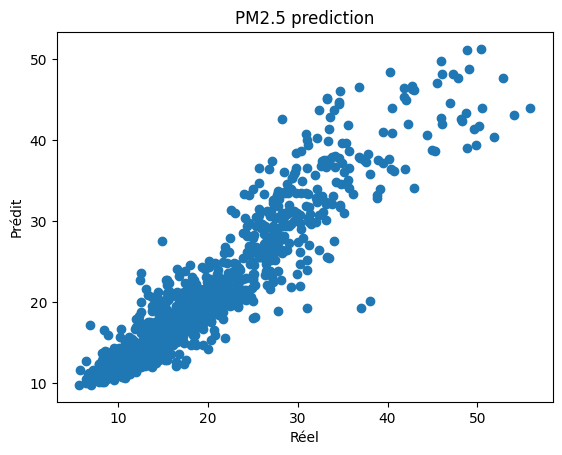

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test["PM2.5"], y_pred[:,1])
plt.xlabel("Réel")
plt.ylabel("Prédit")
plt.title("PM2.5 prediction")

In [22]:
import pandas as pd

def get_feature_importance(model, features):

    # AQI
    aqi_importance = pd.Series(
        model.estimators_[0].feature_importances_,
        index=features
    ).sort_values(ascending=False)

    # PM2.5
    pm25_importance = pd.Series(
        model.estimators_[1].feature_importances_,
        index=features
    ).sort_values(ascending=False)

    return aqi_importance, pm25_importance

In [ ]:
import plotly.express as px

def plot_importance(importance, title):

    df_imp = importance.reset_index()
    df_imp.columns = ["feature", "importance"]

    fig = px.bar(
        df_imp.head(15),
        x="importance",
        y="feature",
        orientation="h",
        title=title
    )

    fig.update_layout(yaxis=dict(autorange="reversed"))

    return fig
aqi_imp, pm_imp = get_feature_importance(model, features)
fig_aqi = plot_importance(aqi_imp, "Importance des variables — AQI")
fig_pm  = plot_importance(pm_imp,  "Importance des variables — PM2.5")

fig_aqi.show()
fig_pm.show()

In [ ]:
def create_features(data):

    df = data.copy()

    # drop propre
    dropped_columns = [
        "european_aqi_pm2_5",
        "carbon_monoxide",
        "methane",
        "wind_direction_10m",
        "soil_temperature_0_to_7cm",
        "soil_moisture_0_to_7cm",
        "precipitation",
        "rain",
        "pressure_msl",
        "surface_pressure",
    ]

    df = df.drop(columns=[col for col in dropped_columns if col in df.columns])

    # date
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df["hour"] = df["date"].dt.hour

    # cyclique
    df.loc[:, "hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df.loc[:, "hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    # lags AQI
    for lag in [1, 3, 6, 24]:
        df.loc[:, f"aqi_lag_{lag}"] = df["european_aqi"].shift(lag)

    # lags PM2.5
    for lag in [1, 3, 24]:
        df.loc[:, f"pm2_5_lag_{lag}"] = df["pm2_5"].shift(lag)

    # targets
    df["PM25"] = df["pm2_5"].shift(-1)
    df["AQI"]  = df["european_aqi"].shift(-1)

    # drop inutiles
    df = df.drop(columns=["hour"])

    df = df.dropna()

    return df

In [ ]:
create_features(data=df_merged)

In [24]:
df = pd.read_csv("data/raw/hourly_quality_air_data.csv", parse_dates=["date"])
df.head(10)

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,1610.0,23.574997,23.574997
1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,1637.0,26.125000,26.125000
2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,1586.0,29.491669,29.491669
3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,1492.0,32.333332,32.333332
4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,1420.0,34.891666,34.891666
5,2025-09-30 05:00:00+00:00,25.000000,27.900000,225.0,447.0,1.7,41.0,6.6,NaN,1396.0,36.799999,36.799999
6,2025-09-30 06:00:00+00:00,22.500000,25.400000,217.0,447.0,1.7,41.0,6.1,NaN,1392.0,38.283333,38.283333
7,2025-09-30 07:00:00+00:00,23.100000,26.100000,214.0,446.0,1.6,42.0,5.4,NaN,1389.0,39.516666,39.516666
8,2025-09-30 08:00:00+00:00,23.600000,26.299999,207.0,442.0,1.5,47.0,4.0,NaN,1379.0,41.200005,41.200005
9,2025-09-30 09:00:00+00:00,14.700000,17.799999,205.0,437.0,1.3,55.0,2.5,NaN,1370.0,43.666672,43.666672


In [25]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df.set_index("date", inplace=True)

### resampling journalier en moyenne

In [26]:
df_daily = df.resample("D").mean()
df_daily.head()

,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5
date,,,,,,,,,,,
2025-09-30 00:00:00+00:00,21.858334,25.350000,287.791667,443.875000,1.750000,52.833333,4.550000,NaN,1413.750000,42.815976,42.815976
2025-10-01 00:00:00+00:00,11.954167,15.979167,203.250000,440.750000,1.179167,61.333333,2.258333,NaN,1369.666667,31.346182,29.464237
2025-10-02 00:00:00+00:00,13.475000,16.275000,237.583333,445.291667,1.150000,45.083333,3.137500,NaN,1400.875000,27.181251,27.181251
2025-10-03 00:00:00+00:00,11.529167,14.708333,217.625000,445.166667,0.937500,45.791667,2.487500,NaN,1381.000000,24.788542,24.078125
2025-10-04 00:00:00+00:00,10.454167,15.083333,185.375000,441.916667,0.750000,45.083333,1.854167,NaN,1351.333333,22.260417,21.173611


## gestion des valeurs manquantes de CH20

In [27]:
if df_daily["formaldehyde"].isnull().mean() >0.5:
    df_daily = df_daily.drop(columns=["formaldehyde"])
else:
    df_daily["formaldehyde"] = df_daily["formaldehyde"].interpolate()


df_daily = df_daily.interpolate(method='linear')

df_daily.head(5)

,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,methane,european_aqi,european_aqi_pm2_5
date,,,,,,,,,,
2025-09-30 00:00:00+00:00,21.858334,25.350000,287.791667,443.875000,1.750000,52.833333,4.550000,1413.750000,42.815976,42.815976
2025-10-01 00:00:00+00:00,11.954167,15.979167,203.250000,440.750000,1.179167,61.333333,2.258333,1369.666667,31.346182,29.464237
2025-10-02 00:00:00+00:00,13.475000,16.275000,237.583333,445.291667,1.150000,45.083333,3.137500,1400.875000,27.181251,27.181251
2025-10-03 00:00:00+00:00,11.529167,14.708333,217.625000,445.166667,0.937500,45.791667,2.487500,1381.000000,24.788542,24.078125
2025-10-04 00:00:00+00:00,10.454167,15.083333,185.375000,441.916667,0.750000,45.083333,1.854167,1351.333333,22.260417,21.173611


In [28]:
# Cible : On veut prévoir le PM2.5 de demain (Shift -1)
df_daily['pm25_diff'] = df_daily['pm2_5'].diff()
# df_daily['target'] = df_daily['pm2_5'].shift(-1)

# Features de retard (Lags)
for i in range(1, 4):
    df_daily[f'pm25_lag_{i}'] = df_daily['pm2_5'].shift(i)
    df_daily[f'co_lag_{i}'] = df_daily['carbon_monoxide'].shift(i)

# Tendance hebdomadaire (Rolling Mean)
df_daily['pm25_rolling_7d'] = df_daily['pm2_5'].rolling(window=7).mean()

# Variables temporelles
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['month'] = df_daily.index.month

# On supprime les lignes vides créées par les décalages (les premières et la dernière)
df_model = df_daily.dropna()

#### entrainement

on entraine le modèle sur le passé pour predire le futur(soit avec les données de sept à fevrier) et tester sur le mars à avril

In [29]:
# Split chronologique (80% train, 20% test)
split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

X_train = train.drop(columns=['pm25_diff'])
y_train = train['pm25_diff']
X_test = test.drop(columns=['pm25_diff'])
y_test = test['pm25_diff']

# Initialisation du modèle XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    early_stopping_rounds=50,
    objective='reg:squarederror'
)

# Entraînement
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

--- RÉSULTATS DU MODÈLE ---
Erreur Moyenne (MAE) : 1.19 µg/m³
Précision (R²) : 0.76


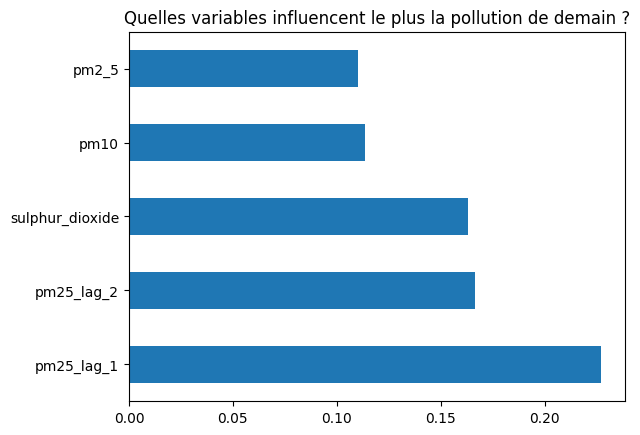

In [30]:
from sklearn.metrics import mean_absolute_error, r2_score
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- RÉSULTATS DU MODÈLE ---")
print(f"Erreur Moyenne (MAE) : {mae:.2f} µg/m³")
print(f"Précision (R²) : {r2:.2f}")

# Visualisation des Features Importantes
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.nlargest(5).plot(kind='barh')
plt.title("Quelles variables influencent le plus la pollution de demain ?")
plt.show()


In [31]:
import joblib

joblib.dump(model, "models/air_quality.pkl")

['models/air_quality.pkl']